In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from tqdm import tqdm_notebook

from sklearn.preprocessing import OneHotEncoder
from keras.utils import to_categorical

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

from keras.layers import Dense,SimpleRNN,LSTM,Embedding
from keras.preprocessing import sequence

from sklearn.preprocessing import StandardScaler,LabelEncoder

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def fnn(X_train, y_train, X_test, y_test, num_features, num_classes, epochs=50, batch_size=32):
    """
    Builds, trains, and evaluates a feedforward neural network for multiclass classification.

    Parameters:
    - X_train: Training features.
    - y_train: Training labels (one-hot encoded).
    - X_test: Testing features.
    - y_test: Testing labels (one-hot encoded).
    - num_features: Number of input features.
    - num_classes: Number of output classes.
    - epochs: Number of training epochs.
    - batch_size: Batch size for training.

    Returns:
    - model: Trained Keras model.
    - evaluation: Evaluation results on the test set (loss, accuracy).
    """
    model = Sequential([
        Dense(64, activation='relu', input_shape=(num_features,)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    evaluation = model.evaluate(X_test, y_test, verbose=0)
    return model, evaluation


In [ ]:
data = pd.read_excel('/content/sample_data/Orginal Air Quality Tehran.xlsx')

data.drop('Time',axis=1,inplace=True)
def probThreshold(inpProb):
    if inpProb  <  51:
        return(0)
    if 50<inpProb < 101:
        return(1)
    if 100<inpProb<151:
        return(2)
    if 150<inpProb<201:
        return(3)
    if 200<inpProb<301:
        return(4)
    else:
        return(5)

data['Outcomes']=data['AQI'].apply(probThreshold)
#print(data[1:10])

X=data.iloc[:,:-2].values
y=data.iloc[:,-1].values
# scaler=StandardScaler()
# X=scaler.fit_transform(X)
# label_encoder=LabelEncoder()
# y=label_encoder.fit_transform(y)
# X=X.reshape((X.shape[0],1,X.shape[1]))


#X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.15,random_state =123)
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=.15, random_state =12)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.176, random_state=12) #0.176 * 0.85 = 0.15

unique, counts = np.unique(y_train, return_counts=True)
print("TrainSet (class: count) = ", dict(zip(unique, counts)), "TrainSize : ", y_train.shape[0])

unique, counts = np.unique(y_test, return_counts=True)
print("TestSet (class: count) =", dict(zip(unique, counts)), "TestSize : ", y_test.shape[0])

unique, counts = np.unique(y_val, return_counts=True)
print("ValSet (class: count) = ", dict(zip(unique, counts)), "ValSize : ", y_val.shape[0])

print(y.shape[0], " = ", (y_train.shape[0] + y_test.shape[0] + y_val.shape[0]))
dummy_y_train = to_categorical(y_train, 6)
print(dummy_y_train)

dummy_y_test = to_categorical(y_test, 6)
print(dummy_y_test)

dummy_y_val = to_categorical(y_val, 6)
print(dummy_y_val)

print(X_train.shape)
print(dummy_y_train.shape)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_test_scaled.shape)
print(X_train_scaled.shape)
print(dummy_y_train.shape)

TrainSet (class: count) =  {0: 54, 1: 835, 2: 339, 3: 48, 4: 1, 5: 1} TrainSize :  1278
TestSet (class: count) = {0: 12, 1: 185, 2: 70, 3: 7, 5: 1} TestSize :  275
ValSet (class: count) =  {0: 13, 1: 176, 2: 78, 3: 6, 4: 1} ValSize :  274
1827  =  1827
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]]
(1278, 14)
(1278, 6)
(275, 14)
(1278, 14)
(1278, 6)


In [ ]:
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
# Define the FNN model for classification
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(64, activation='relu'),
    Dense(dummy_y_train.shape[1], activation='softmax')  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, dummy_y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=2)
Predictions=model.predict(X_test_scaled).argmax(axis=1)
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, dummy_y_test, verbose=2)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Epoch 1/50
36/36 - 2s - loss: 1.3693 - accuracy: 0.5374 - val_loss: 0.8469 - val_accuracy: 0.7734 - 2s/epoch - 64ms/step
Epoch 2/50
36/36 - 0s - loss: 0.7557 - accuracy: 0.7852 - val_loss: 0.5612 - val_accuracy: 0.8359 - 224ms/epoch - 6ms/step
Epoch 3/50
36/36 - 0s - loss: 0.5501 - accuracy: 0.8357 - val_loss: 0.4215 - val_accuracy: 0.8594 - 169ms/epoch - 5ms/step
Epoch 4/50
36/36 - 0s - loss: 0.4528 - accuracy: 0.8443 - val_loss: 0.3656 - val_accuracy: 0.8750 - 143ms/epoch - 4ms/step
Epoch 5/50
36/36 - 0s - loss: 0.3909 - accuracy: 0.8696 - val_loss: 0.3515 - val_accuracy: 0.8594 - 157ms/epoch - 4ms/step
Epoch 6/50
36/36 - 0s - loss: 0.3476 - accuracy: 0.8809 - val_loss: 0.3230 - val_accuracy: 0.8828 - 192ms/epoch - 5ms/step
Epoch 7/50
36/36 - 0s - loss: 0.3180 - accuracy: 0.8843 - val_loss: 0.2959 - val_accuracy: 0.8906 - 179ms/epoch - 5ms/step
Epoch 8/50
36/36 - 0s - loss: 0.2876 - accuracy: 0.9026 - val_loss: 0.2867 - val_accuracy: 0.8828 - 164ms/epoch - 5ms/step
Epoch 9/50
36/36 -

0.92
0.587104247104247
0.6104597065053528
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        12
           1       0.94      0.98      0.96       185
           2       0.90      0.89      0.89        70
           3       0.50      0.57      0.53         7
           5       0.00      0.00      0.00         1

    accuracy                           0.92       275
   macro avg       0.67      0.59      0.61       275
weighted avg       0.92      0.92      0.92       275



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


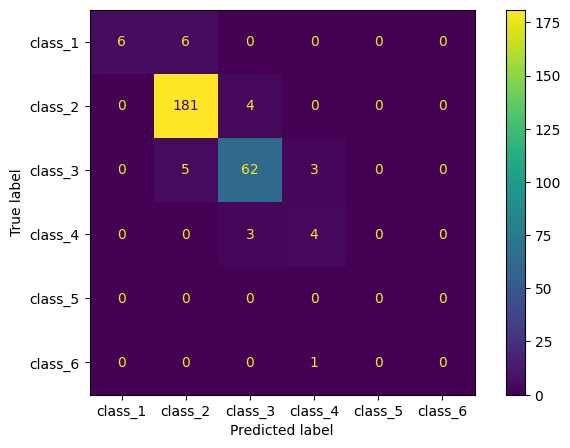

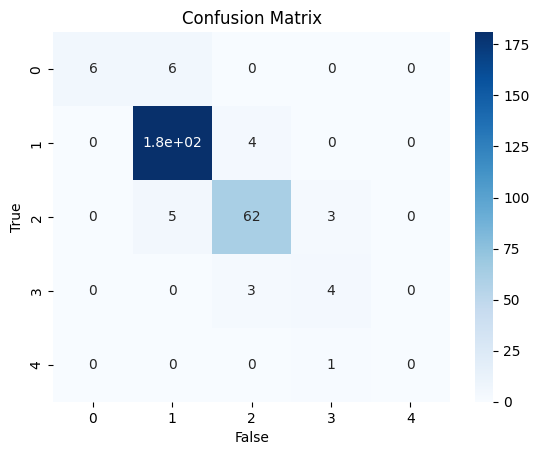

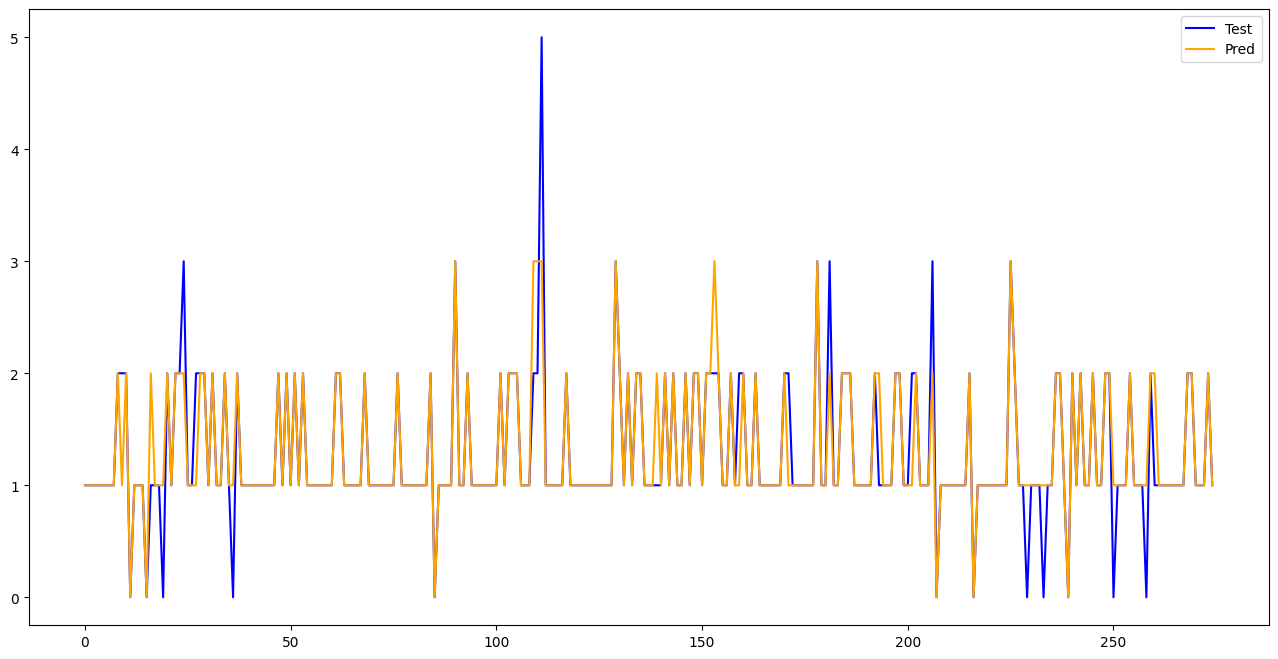

In [ ]:
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# print(metrics.classification_report(y_test, Predictions))
# print(metrics.confusion_matrix(y_test, Predictions))
# print(metrics.precision_score(y_test, Predictions))
print(accuracy_score(dummy_y_test.argmax(axis=1),Predictions))
print(balanced_accuracy_score(dummy_y_test.argmax(axis=1),Predictions))
print(f1_score(dummy_y_test.argmax(axis=1),Predictions,average='macro'))
print(classification_report(dummy_y_test.argmax(axis=1), Predictions))
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(confusion_matrix(dummy_y_test.argmax(axis=1), Predictions,
                                              labels=[0, 1, 2, 3, 4, 5])
                            ,display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"],)
cmp.plot(ax=ax)
plt.show()
conf_matrix = confusion_matrix(dummy_y_test.argmax(axis=1), Predictions)
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.ylabel('True')
plt.xlabel('False')
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(16,8))
plt.plot(dummy_y_test.argmax(axis=1), color='blue', label='Test')
plt.plot(Predictions, color='orange', label='Pred')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import classification_report,accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print(accuracy_score(y_test, tes))
print(balanced_accuracy_score(y_test,y_pred))
print(f1_score(y_test,y_pred,average='macro'))
print(classification_report(y_test, y_pred))
# dot_data = tree.export_graphviz(models, out_file=None, filled=True, rounded=True)
# graph = pydotplus.graph_from_dot_data(dot_data)
# display(Image(data=graph.create_png()))
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5]), display_labels=["class_1", "class_2", "class_3","class_4","class_5","class_6"],)
cmp.plot(ax=ax)
plt.show()
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, cmap= 'Blues')
plt.ylabel('True')
plt.xlabel('False')
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(16,8))
plt.plot(y_test, color='blue', label='Test')
plt.plot(y_pred, color='orange', label='Pred')
plt.legend()
plt.show()

In [ ]:
# Example Usage:
# Generate synthetic data
num_features = 14
num_classes = 6




# Train and evaluate the FNN
model, evaluation = fnn(X_train_scaled, dummy_y_train, X_test_scaled, dummy_y_test, num_features, num_classes)
model
print(f"Test Loss: {evaluation[0]}, Test Accuracy: {evaluation[1]}")

Test Loss: 0.2940983176231384, Test Accuracy: 0.9127272963523865


In [ ]:
class FFSNNetwork:

  def __init__(self, n_inputs, hidden_sizes=[2]):
    #intialize the inputs
    self.nx = n_inputs
    self.ny = 1
    self.nh = len(hidden_sizes)
    self.sizes = [self.nx] + hidden_sizes + [self.ny]

    self.W = {}
    self.B = {}
    for i in range(self.nh+1):
      self.W[i+1] = np.random.randn(self.sizes[i], self.sizes[i+1])
      self.B[i+1] = np.zeros((1, self.sizes[i+1]))

  def sigmoid(self, x):
    return 1.0/(1.0 + np.exp(-x))

  def forward_pass(self, x):
    self.A = {}
    self.H = {}
    self.H[0] = x.reshape(1, -1)
    for i in range(self.nh+1):
      self.A[i+1] = np.matmul(self.H[i], self.W[i+1]) + self.B[i+1]
      self.H[i+1] = self.sigmoid(self.A[i+1])
    return self.H[self.nh+1]

  def grad_sigmoid(self, x):
    return x*(1-x)

  def grad(self, x, y):
    self.forward_pass(x)
    self.dW = {}
    self.dB = {}
    self.dH = {}
    self.dA = {}
    L = self.nh + 1
    self.dA[L] = (self.H[L] - y)
    for k in range(L, 0, -1):
      self.dW[k] = np.matmul(self.H[k-1].T, self.dA[k])
      self.dB[k] = self.dA[k]
      self.dH[k-1] = np.matmul(self.dA[k], self.W[k].T)
      self.dA[k-1] = np.multiply(self.dH[k-1], self.grad_sigmoid(self.H[k-1]))

  def fit(self, X, Y, epochs=1, learning_rate=1, initialise=True, display_loss=False):

    # initialise w, b
    if initialise:
      for i in range(self.nh+1):
        self.W[i+1] = np.random.randn(self.sizes[i], self.sizes[i+1])
        self.B[i+1] = np.zeros((1, self.sizes[i+1]))

    if display_loss:
      loss = {}

    for e in tqdm_notebook(range(epochs), total=epochs, unit="epoch"):
      dW = {}
      dB = {}
      for i in range(self.nh+1):
        dW[i+1] = np.zeros((self.sizes[i], self.sizes[i+1]))
        dB[i+1] = np.zeros((1, self.sizes[i+1]))
      for x, y in zip(X, Y):
        self.grad(x, y)
        for i in range(self.nh+1):
          dW[i+1] += self.dW[i+1]
          dB[i+1] += self.dB[i+1]

      m = X.shape[1]
      for i in range(self.nh+1):
        self.W[i+1] -= learning_rate * dW[i+1] / m
        self.B[i+1] -= learning_rate * dB[i+1] / m

      if display_loss:
        Y_pred = self.predict(X)
        loss[e] = mean_squared_error(Y_pred, Y)

    if display_loss:
      plt.plot(loss.values())
      plt.xlabel('Epochs')
      plt.ylabel('Mean Squared Error')
      plt.show()

  def predict(self, X):
    Y_pred = []
    for x in X:
      y_pred = self.forward_pass(x)
      Y_pred.append(y_pred)
    return np.array(Y_pred).squeeze()

<ipython-input-3-b9a3d6b21708>:56: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for e in tqdm_notebook(range(epochs), total=epochs, unit="epoch"):


  0%|          | 0/1000 [00:00<?, ?epoch/s]

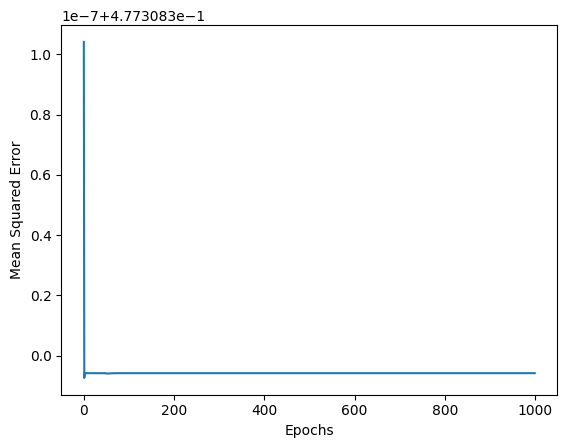

Training accuracy 0.65
Validation accuracy 0.64


In [ ]:
#train the network with two hidden layers - 2 neurons and 3 neurons
ffsnn = FFSNNetwork(14, [21, 32])
ffsnn.fit(X_train, y_train, epochs=1000, learning_rate=.001, display_loss=True)

Y_pred_train = ffsnn.predict(X_train)
Y_pred_binarised_train = (Y_pred_train >= 0.5).astype("int").ravel()
Y_pred_val = ffsnn.predict(X_val)
Y_pred_binarised_val = (Y_pred_val >= 0.5).astype("int").ravel()
accuracy_train = accuracy_score(Y_pred_binarised_train, y_train)
accuracy_val = accuracy_score(Y_pred_binarised_val, y_val)

print("Training accuracy", round(accuracy_train, 2))
print("Validation accuracy", round(accuracy_val, 2))
